In [12]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ================================
# STYLE SETTINGS (PRO LOOK 🔥)
# ================================
sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (8,5)

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("eventsd1.csv")

# ================================
# CREATE LABELS
# ================================
df['actual'] = df['Zone'].apply(lambda x: 1 if x == 'BlindSpot' else 0)
df['predicted'] = df['Object'].apply(lambda x: 1 if str(x).lower() == 'person' else 0)

y_true = df['actual']
y_pred = df['predicted']

# ================================
# METRICS
# ================================
cm = confusion_matrix(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n===== METRICS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ================================
# 🎨 1. CONFUSION MATRIX (COLORFUL 🔥)
# ================================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', linewidths=2, linecolor='black')

plt.title("Confusion Matrix

SyntaxError: unterminated string literal (detected at line 60) (1783831588.py, line 60)


===== METRICS =====
Accuracy  : 0.8800
Precision : 0.8664
Recall    : 0.8584
F1 Score  : 0.8624


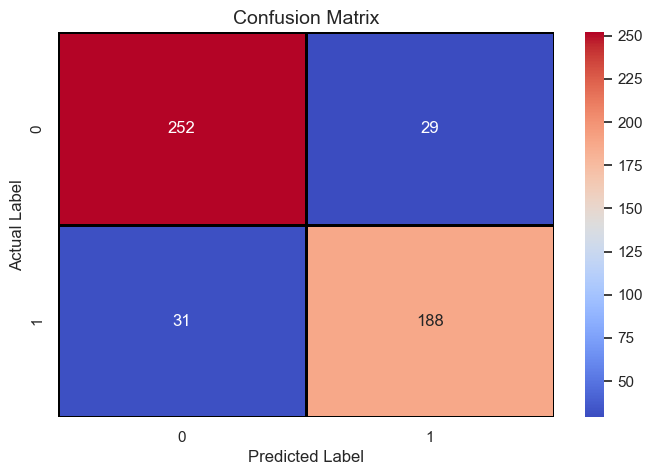

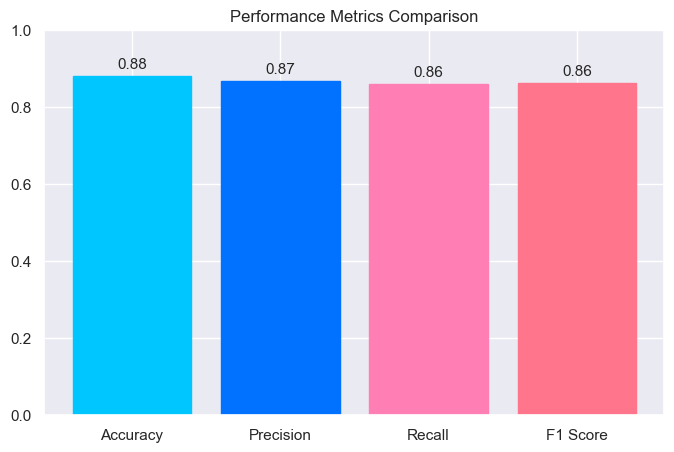

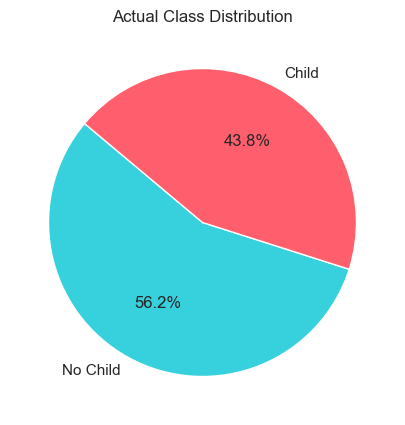

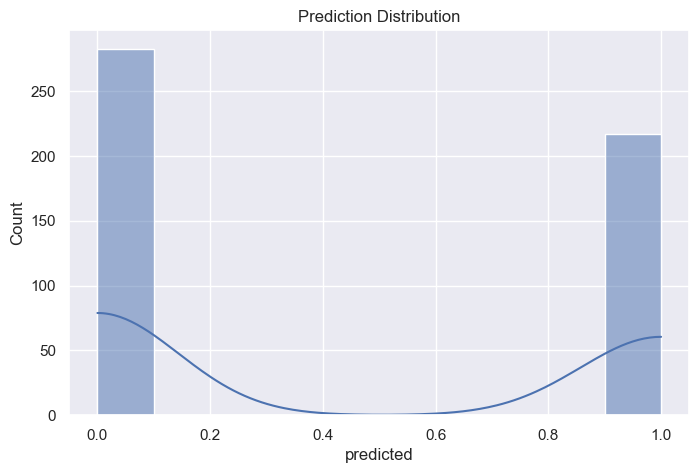

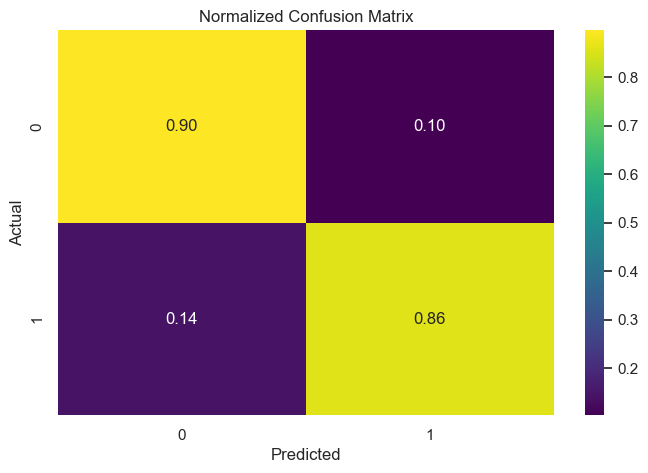


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       281
           1       0.87      0.86      0.86       219

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500


✅ Report saved!


In [ ]:
", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# ================================
# 📊 2. METRIC COMPARISON BAR 🔥
# ================================
metrics = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure()
bars = plt.bar(labels, metrics)

# Add gradient colors
colors = ['#00c6ff', '#0072ff', '#ff7eb3', '#ff758c']
for bar, color in zip(bars, colors):
    bar.set_color(color)

for i, v in enumerate(metrics):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.ylim(0,1)
plt.title("Performance Metrics Comparison")
plt.show()

# ================================
# 🧩 3. PIE CHART (CLASS BALANCE 🔥)
# ================================
plt.figure()
counts = y_true.value_counts()

plt.pie(counts, labels=["No Child", "Child"], autopct='%1.1f%%', startangle=140,
        colors=['#36d1dc', '#ff5f6d'])

plt.title("Actual Class Distribution")
plt.show()

# ================================
# 📈 4. DISTRIBUTION PLOT 🔥
# ================================
plt.figure()
sns.histplot(y_pred, kde=True)

plt.title("Prediction Distribution")
plt.show()

# ================================
# 📊 5. HEATMAP OF NORMALIZED CM 🔥
# ================================
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
sns.heatmap(cm_norm, annot=True, cmap='viridis', fmt='.2f')

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 📄 CLASSIFICATION REPORT
# ================================
report = classification_report(y_true, y_pred, zero_division=0)
print("\n===== CLASSIFICATION REPORT =====")
print(report)

# ================================
# SAVE REPORT
# ================================
with open("evaluation_report.txt", "w") as f:
    f.write("===== MODEL EVALUATION =====\n\n")
    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n\n")
    f.write(report)

print("\n✅ Report saved!")